# Phân cụm và phân lớp khách hàng thương mại điện tử

Notebook này thực hiện đầy đủ các yêu cầu: k-Means, DBSCAN, k-NN và SVM trên bộ dữ liệu đã gửi. Dữ liệu chính dùng cho mô hình là `customers.csv`. Các file `orders.csv`, `monthly_revenue.csv` và `product_summary.csv` được đọc trực tiếp để kiểm tra cấu trúc dữ liệu, không giải nén zip và không tạo lại bảng khách hàng từ đầu.

Các bước chính gồm: đọc dữ liệu CSV, khám phá dữ liệu, tiền xử lý, chọn biến, giảm chiều bằng PCA, phân cụm bằng k-Means, phân cụm bằng DBSCAN, so sánh mô hình phân cụm, phân lớp bằng k-NN, phân lớp bằng SVM và đánh giá kết quả.

## 1. Import thư viện

In [69]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.neighbors import NearestNeighbors, KNeighborsClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    RocCurveDisplay
)

RANDOM_STATE = 42
pd.set_option("display.max_columns", 100)
plt.rcParams["figure.figsize"] = (8, 5)

## 2. Đọc dữ liệu trực tiếp từ các file CSV

Phần này đọc trực tiếp từng file CSV. Notebook không dùng file zip và không dùng lệnh giải nén. Khi chạy trên Colab, hãy upload các file `customers.csv`, `orders.csv`, `monthly_revenue.csv` và `product_summary.csv` vào cùng thư mục với notebook.

In [70]:
import pandas as pd

# Đọc file CSV
customers = pd.read_csv("customers.csv")

# Xem 5 dòng đầu
customers.head()

,customer_id,country,age,gender,membership_tier,registration_date,total_orders,total_spend_usd,avg_order_value_usd,days_since_last_purchase,preferred_category,preferred_device,preferred_payment_method,acquisition_channel,reviews_given,avg_review_score,returns_made,wishlist_items,newsletter_subscribed,churned
0,C00001,United States,40,Male,Free,2019-01-17,4,286.63,63.78,49,Food & Grocery,Mobile,Debit Card,Social Media,1,4.5,0,12,0,0
1,C00002,United States,20,Female,Free,2026-03-04,11,1245.18,107.32,126,Toys & Games,Mobile,Debit Card,Organic Search,2,2.6,1,1,0,0
2,C00003,United States,43,Female,Gold,2026-02-08,4,195.37,42.74,0,Home & Kitchen,Mobile,PayPal,Referral,0,4.8,0,0,1,0
3,C00004,United States,41,Male,Free,2025-03-19,6,99.45,15.61,6,Electronics,Desktop,PayPal,Organic Search,2,4.2,0,8,1,0
4,C00005,France,37,Other,Platinum,2024-09-10,36,2593.21,79.09,161,Clothing & Apparel,Tablet,Debit Card,Social Media,9,4.0,4,5,1,0


**giải thích các biến **

- customer_id: Mã định danh khách hàng
- country: Quốc gia của khách hàng
- age: Tuổi khách hàng
- gender: Giới tính khách hàng
- membership_tier: Hạng thành viên
- registration_date: Ngày khách hàng đăng ký
- total_orders: Tổng số đơn hàng
- total_spend_usd: Tổng số tiền đã chi tiêu (USD)
- avg_order_value_usd: Giá trị trung bình mỗi đơn hàng (USD)
- days_since_last_purchase: Số ngày kể từ lần mua gần nhất
- preferred_category: Danh mục sản phẩm thường mua
- preferred_device: Thiết bị thường dùng để mua hàng
- preferred_payment_method: Phương thức thanh toán ưa thích
- acquisition_channel: Kênh thu hút khách hàng
- reviews_given: Số lượt đánh giá đã viết
- avg_review_score: Điểm đánh giá trung bình
- returns_made: Số lần trả hàng
- wishlist_items: Số sản phẩm trong danh sách yêu thích
- newsletter_subscribed: Trạng thái đăng ký nhận bản tin (1: Có, 0: Không)
- churned: Trạng thái rời bỏ khách hàng (1: Đã rời bỏ, 0: Chưa rời bỏ)



## 3. Khám phá dữ liệu ban đầu

Bảng customers.csv đã là bảng khách hàng. Vì vậy notebook dùng bảng này làm dữ liệu chính cho mô hình. Không cần tổng hợp lại khách hàng từ orders.csv.

In [71]:
print("Thông tin customers.csv")
print(customers.info())

Thông tin customers.csv
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   customer_id               8000 non-null   object 
 1   country                   8000 non-null   object 
 2   age                       8000 non-null   int64  
 3   gender                    8000 non-null   object 
 4   membership_tier           8000 non-null   object 
 5   registration_date         8000 non-null   object 
 6   total_orders              8000 non-null   int64  
 7   total_spend_usd           8000 non-null   float64
 8   avg_order_value_usd       8000 non-null   float64
 9   days_since_last_purchase  8000 non-null   int64  
 10  preferred_category        8000 non-null   object 
 11  preferred_device          8000 non-null   object 
 12  preferred_payment_method  8000 non-null   object 
 13  acquisition_channel       8000 non-null

Thông kê các dữ liệu thiếu cũng như là độ chênh lệch của các dữ liệu


In [72]:
summary_table = pd.DataFrame({
    "dtype": customers.dtypes.astype(str),
    "missing": customers.isna().sum(),
    "missing_rate": customers.isna().mean().round(4),
    "n_unique": customers.nunique()
})
summary_table

,dtype,missing,missing_rate,n_unique
customer_id,object,0,0.0,8000
country,object,0,0.0,20
age,int64,0,0.0,57
gender,object,0,0.0,3
membership_tier,object,0,0.0,4
registration_date,object,0,0.0,1862
total_orders,int64,0,0.0,79
total_spend_usd,float64,0,0.0,7864
avg_order_value_usd,float64,0,0.0,6365
days_since_last_purchase,int64,0,0.0,336


biểu đồ phân bổ giá trị biến mục tiêu churned

Phân bố biến mục tiêu churned
churned
0    7285
1     715
Name: count, dtype: int64
churned
0    0.9106
1    0.0894
Name: proportion, dtype: float64


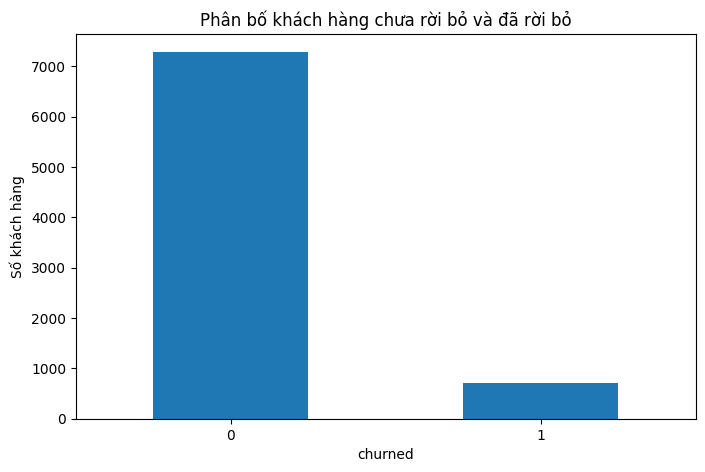

In [73]:
print("Phân bố biến mục tiêu churned")
print(customers["churned"].value_counts())
print(customers["churned"].value_counts(normalize=True).round(4))

customers["churned"].value_counts().sort_index().plot(kind="bar")
plt.title("Phân bố khách hàng chưa rời bỏ và đã rời bỏ")
plt.xlabel("churned")
plt.ylabel("Số khách hàng")
plt.xticks(rotation=0)
plt.show()

In [74]:
num_cols_overview = customers.select_dtypes(include=["int64", "float64"]).columns.tolist()
customers[num_cols_overview].describe().T

,count,mean,std,min,25%,50%,75%,max
age,8000.0,35.616375,11.170455,18.00,27.000,35.00,43.000,75.00
total_orders,8000.0,16.545250,14.681064,1.00,5.000,12.00,23.000,79.00
total_spend_usd,8000.0,1558.642350,2284.094953,4.89,336.055,845.70,1892.165,61282.48
avg_order_value_usd,8000.0,94.845566,78.992885,5.00,44.690,72.27,118.560,1051.73
days_since_last_purchase,8000.0,59.583875,60.610355,0.00,16.000,41.00,84.000,582.00
reviews_given,8000.0,3.228750,3.942698,0.00,0.000,2.00,5.000,28.00
avg_review_score,8000.0,4.109112,0.523992,1.80,3.800,4.20,4.500,5.00
returns_made,8000.0,0.849500,1.407337,0.00,0.000,0.00,1.000,11.00
wishlist_items,8000.0,4.457125,4.854391,0.00,1.000,3.00,6.000,41.00
newsletter_subscribed,8000.0,0.617375,0.486058,0.00,0.000,1.00,1.000,1.00


## 4. Tiền xử lý dữ liệu và chọn biến

Phần này không tạo bộ dữ liệu khách hàng mới. Mục tiêu là làm sạch, biến đổi kiểu dữ liệu và chọn các biến phù hợp từ `customers.csv` để đưa vào mô hình.

Các biến không dùng trực tiếp cho mô hình gồm `customer_id` vì đây là mã định danh, `registration_date` vì đã được chuyển thành biến số `customer_tenure_days`, và `churned` vì đây là biến mục tiêu cho bài toán phân lớp.

In [75]:
model_df = customers.copy()

# Chuyển ngày đăng ký sang kiểu datetime
model_df["registration_date"] = pd.to_datetime(model_df["registration_date"], errors="coerce")

# Mốc thời gian tham chiếu lấy từ ngày lớn nhất trong dữ liệu khách hàng
reference_date = model_df["registration_date"].max()
model_df["customer_tenure_days"] = (reference_date - model_df["registration_date"]).dt.days

# Chuẩn hóa một số cột nhị phân về dạng số nếu cần
binary_columns = ["newsletter_subscribed", "churned"]
for col in binary_columns:
    if col in model_df.columns:
        model_df[col] = pd.to_numeric(model_df[col], errors="coerce")



print("Kích thước dữ liệu sau xử lý ban đầu:", model_df.shape)
model_df.head()

Kích thước dữ liệu sau xử lý ban đầu: (8000, 21)


,customer_id,country,age,gender,membership_tier,registration_date,total_orders,total_spend_usd,avg_order_value_usd,days_since_last_purchase,preferred_category,preferred_device,preferred_payment_method,acquisition_channel,reviews_given,avg_review_score,returns_made,wishlist_items,newsletter_subscribed,churned,customer_tenure_days
0,C00001,United States,40,Male,Free,2019-01-17,4,286.63,63.78,49,Food & Grocery,Mobile,Debit Card,Social Media,1,4.5,0,12,0,0,2631
1,C00002,United States,20,Female,Free,2026-03-04,11,1245.18,107.32,126,Toys & Games,Mobile,Debit Card,Organic Search,2,2.6,1,1,0,0,28
2,C00003,United States,43,Female,Gold,2026-02-08,4,195.37,42.74,0,Home & Kitchen,Mobile,PayPal,Referral,0,4.8,0,0,1,0,52
3,C00004,United States,41,Male,Free,2025-03-19,6,99.45,15.61,6,Electronics,Desktop,PayPal,Organic Search,2,4.2,0,8,1,0,378
4,C00005,France,37,Other,Platinum,2024-09-10,36,2593.21,79.09,161,Clothing & Apparel,Tablet,Debit Card,Social Media,9,4.0,4,5,1,0,568


xử lý các giá trị ngoại lai

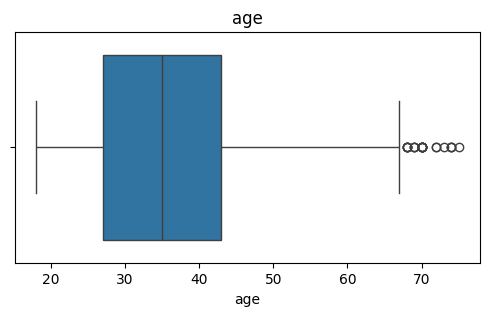

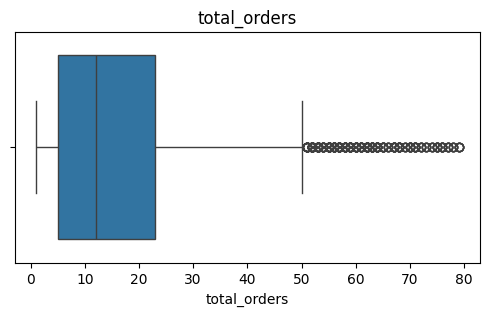

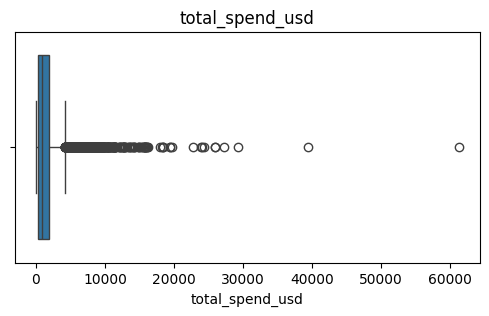

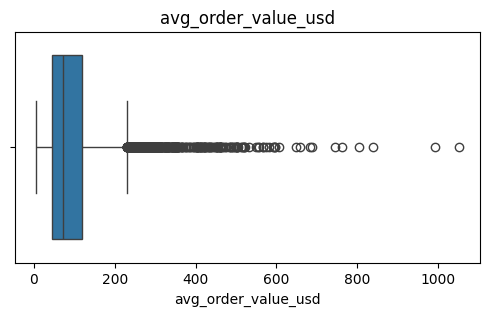

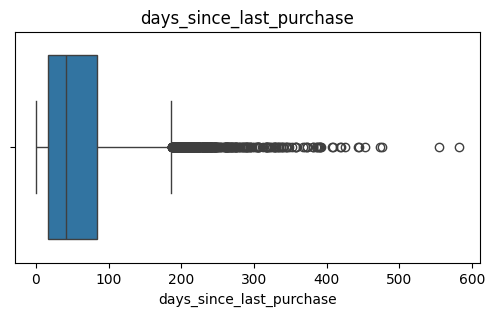

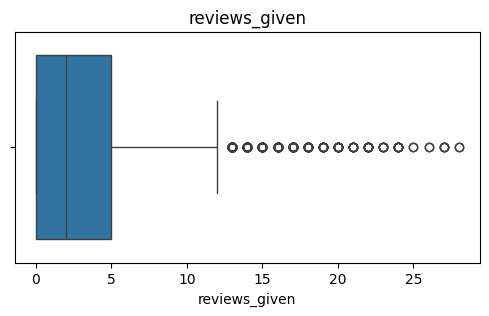

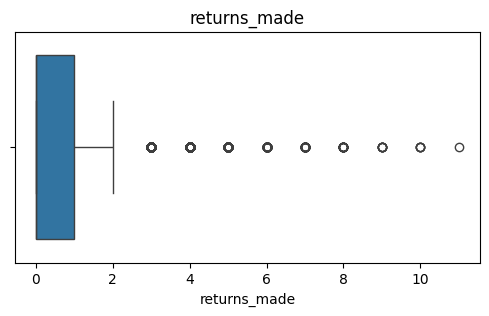

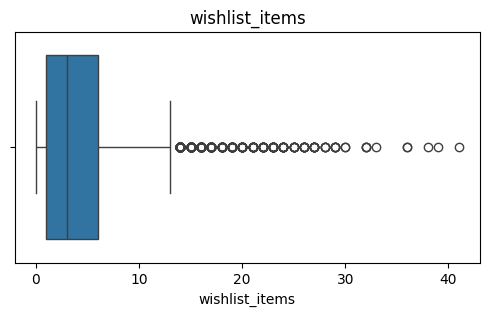

In [76]:
import matplotlib.pyplot as plt
import seaborn as sns

num_cols = [
    'age',
    'total_orders',
    'total_spend_usd',
    'avg_order_value_usd',
    'days_since_last_purchase',
    'reviews_given',
    'returns_made',
    'wishlist_items'
]

for col in num_cols:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=customers[col])
    plt.title(col)
    plt.show()

thống kê số giá trị ngoại lai của từng biến


In [77]:
outlier_summary = []

for col in num_cols:

    Q1 = customers[col].quantile(0.25)
    Q3 = customers[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    n_outliers = (
        (customers[col] < lower) |
        (customers[col] > upper)
    ).sum()

    outlier_summary.append(
        [col, n_outliers]
    )

outlier_summary = pd.DataFrame(
    outlier_summary,
    columns=["Variable", "Outliers"]
)

print(outlier_summary)

                   Variable  Outliers
0                       age        23
1              total_orders       313
2           total_spend_usd       619
3       avg_order_value_usd       477
4  days_since_last_purchase       351
5             reviews_given       302
6              returns_made       888
7            wishlist_items       478


In [78]:
for col in num_cols:

    Q1 = customers[col].quantile(0.25)
    Q3 = customers[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    customers[col] = customers[col].clip(
        lower,
        upper
    )

 **lựa chọn các biến cho phân cụm**

In [79]:
# Chọn biến cho phân cụm
# Không đưa churned vào phân cụm vì phân cụm là học không giám sát.
exclude_for_clustering = ["customer_id", "registration_date", "churned"]
cluster_features = [col for col in model_df.columns if col not in exclude_for_clustering]

# Chọn biến cho phân lớp
# Không đưa customer_id và registration_date gốc vào mô hình.
exclude_for_classification = ["customer_id", "registration_date", "churned"]
classification_features = [col for col in model_df.columns if col not in exclude_for_classification]

target_col = "churned"

print("Số biến dùng cho phân cụm:", len(cluster_features))
print(cluster_features)
print("\nSố biến dùng cho phân lớp:", len(classification_features))
print(classification_features)

Số biến dùng cho phân cụm: 18
['country', 'age', 'gender', 'membership_tier', 'total_orders', 'total_spend_usd', 'avg_order_value_usd', 'days_since_last_purchase', 'preferred_category', 'preferred_device', 'preferred_payment_method', 'acquisition_channel', 'reviews_given', 'avg_review_score', 'returns_made', 'wishlist_items', 'newsletter_subscribed', 'customer_tenure_days']

Số biến dùng cho phân lớp: 18
['country', 'age', 'gender', 'membership_tier', 'total_orders', 'total_spend_usd', 'avg_order_value_usd', 'days_since_last_purchase', 'preferred_category', 'preferred_device', 'preferred_payment_method', 'acquisition_channel', 'reviews_given', 'avg_review_score', 'returns_made', 'wishlist_items', 'newsletter_subscribed', 'customer_tenure_days']


In [80]:
# Tách biến số và biến phân loại
numeric_features = model_df[cluster_features].select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = model_df[cluster_features].select_dtypes(include=["object", "category", "bool"]).columns.tolist()

print("Biến số:", numeric_features)
print("Biến phân loại:", categorical_features)

Biến số: ['age', 'total_orders', 'total_spend_usd', 'avg_order_value_usd', 'days_since_last_purchase', 'reviews_given', 'avg_review_score', 'returns_made', 'wishlist_items', 'newsletter_subscribed', 'customer_tenure_days']
Biến phân loại: ['country', 'gender', 'membership_tier', 'preferred_category', 'preferred_device', 'preferred_payment_method', 'acquisition_channel']



Mã hóa biến phân loại
Chuẩn hóa biến số
Tạo ma trận dữ liệu số để phân cụm

In [81]:
def make_one_hot_encoder():
    """Tạo OneHotEncoder tương thích với nhiều phiên bản scikit-learn."""
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)

# Pipeline cho biến số
numeric_transformer = Pipeline(steps=[
    ("scaler", StandardScaler())
])

# Pipeline cho biến phân loại
categorical_transformer = Pipeline(steps=[
    ("onehot", make_one_hot_encoder())
])

# Áp dụng tiền xử lý cho từng nhóm biến
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ],
    remainder="drop"
)

# Dữ liệu dùng để phân cụm
X_cluster_raw = model_df[cluster_features]

# Chuẩn hóa và mã hóa
X_cluster_processed = preprocessor.fit_transform(X_cluster_raw)

print("Số chiều dữ liệu sau chuẩn hóa và mã hóa:",
      X_cluster_processed.shape)

Số chiều dữ liệu sau chuẩn hóa và mã hóa: (8000, 68)






## 5. Giảm chiều dữ liệu bằng PCA

Sau khi chuẩn hóa và mã hóa biến phân loại, dữ liệu có nhiều chiều hơn dữ liệu gốc. PCA được dùng để giảm chiều dữ liệu, giữ lại phần lớn phương sai và tạo không gian 2 chiều để trực quan hóa.

In [82]:
# PCA dùng cho mô hình phân cụm: giảm còn tối đa 10 thành phần chính
# Cách này giúp k-Means, DBSCAN, k-NN và SVM chạy nhẹ hơn trên Colab.
N_PCA_COMPONENTS = min(10, X_cluster_processed.shape[1])

pca_model = PCA(n_components=N_PCA_COMPONENTS, random_state=RANDOM_STATE)
X_pca = pca_model.fit_transform(X_cluster_processed)

# PCA 2 chiều dùng để vẽ biểu đồ
pca_2d = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca_2d = pca_2d.fit_transform(X_cluster_processed)

# Lấy mẫu để chọn tham số nhanh hơn. Mô hình cuối vẫn được gán nhãn cho toàn bộ dữ liệu.
CLUSTER_SAMPLE_SIZE = min(3000, X_pca.shape[0])
rng = np.random.default_rng(RANDOM_STATE)
cluster_sample_idx = rng.choice(X_pca.shape[0], size=CLUSTER_SAMPLE_SIZE, replace=False)
X_pca_sample = X_pca[cluster_sample_idx]

print("Số chiều ban đầu sau tiền xử lý:", X_cluster_processed.shape[1])
print("Số chiều sau PCA:", X_pca.shape[1])
print("Tổng phương sai được giữ lại:", round(pca_model.explained_variance_ratio_.sum(), 4))
print("Phương sai của PCA 2D:", pca_2d.explained_variance_ratio_.round(4))

Số chiều ban đầu sau tiền xử lý: 68
Số chiều sau PCA: 10
Tổng phương sai được giữ lại: 0.6962
Phương sai của PCA 2D: [0.181  0.0847]


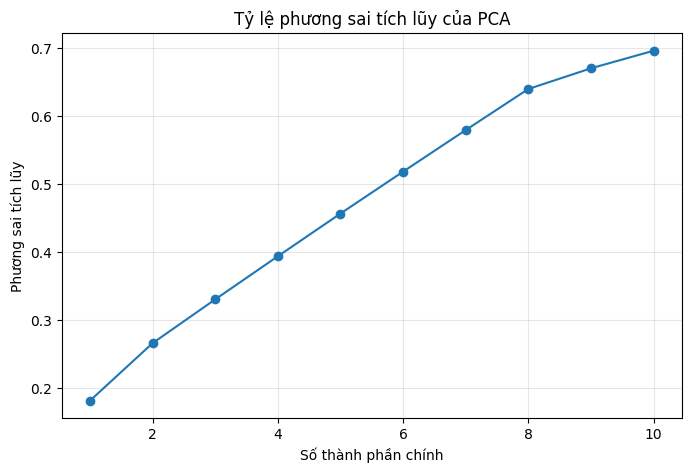

In [83]:
explained = np.cumsum(pca_model.explained_variance_ratio_)

plt.plot(range(1, len(explained) + 1), explained, marker="o")
plt.title("Tỷ lệ phương sai tích lũy của PCA")
plt.xlabel("Số thành phần chính")
plt.ylabel("Phương sai tích lũy")
plt.grid(True, alpha=0.3)
plt.show()

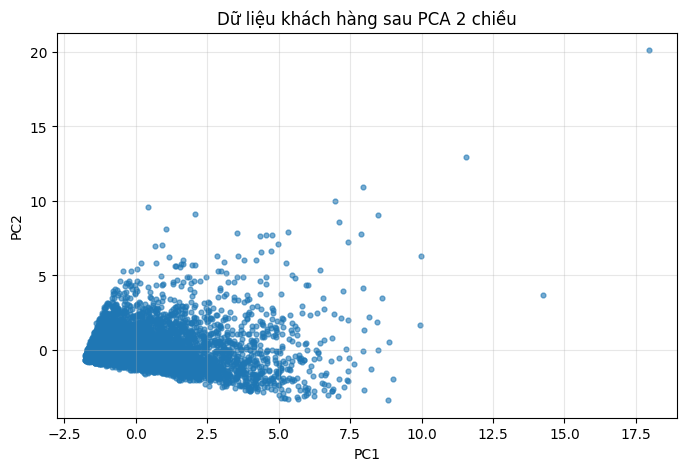

In [84]:
plt.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], s=12, alpha=0.6)
plt.title("Dữ liệu khách hàng sau PCA 2 chiều")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True, alpha=0.3)
plt.show()

## 6. k-Means: chọn số cụm bằng Elbow Method và Silhouette Score

k-Means được chạy trên dữ liệu đã giảm chiều bằng PCA. Elbow Method dùng để quan sát độ giảm của inertia. Silhouette Score dùng để đánh giá mức độ tách cụm. Phần chọn k dùng một mẫu dữ liệu để notebook chạy nhanh hơn, sau đó mô hình cuối được huấn luyện và gán nhãn trên toàn bộ khách hàng.

In [85]:
def safe_silhouette(X, labels, sample_size=2000):
    """Tính Silhouette trên mẫu để tránh tốn bộ nhớ khi dữ liệu lớn."""
    labels = np.asarray(labels)
    if len(set(labels)) < 2:
        return np.nan
    n_sample = min(sample_size, len(labels))
    return silhouette_score(
        X,
        labels,
        sample_size=n_sample,
        random_state=RANDOM_STATE
    )

k_values = range(2, 11)
inertias = []
silhouette_scores = []

for k in k_values:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=5, max_iter=100)
    labels = km.fit_predict(X_pca_sample)
    inertias.append(km.inertia_)
    silhouette_scores.append(safe_silhouette(X_pca_sample, labels))

kmeans_eval = pd.DataFrame({
    "k": list(k_values),
    "inertia": inertias,
    "silhouette": silhouette_scores
})

kmeans_eval

,k,inertia,silhouette
0,2,28163.389342,0.236263
1,3,25758.251851,0.133584
2,4,23981.396291,0.135595
3,5,23104.177664,0.117676
4,6,21345.229069,0.134133
5,7,20347.593475,0.123958
6,8,19316.200878,0.124869
7,9,18654.489211,0.109925
8,10,18036.223332,0.113593


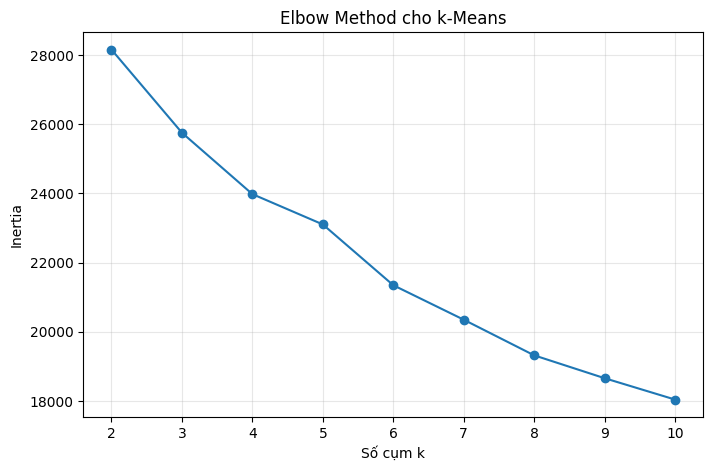

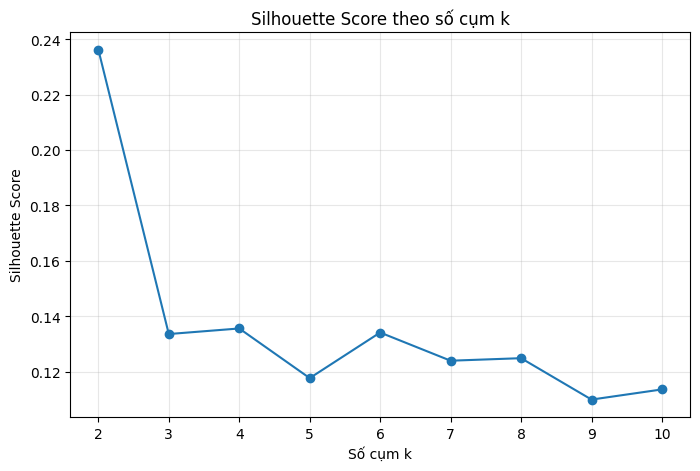

In [86]:
plt.plot(kmeans_eval["k"], kmeans_eval["inertia"], marker="o")
plt.title("Elbow Method cho k-Means")
plt.xlabel("Số cụm k")
plt.ylabel("Inertia")
plt.grid(True, alpha=0.3)
plt.show()

plt.plot(kmeans_eval["k"], kmeans_eval["silhouette"], marker="o")
plt.title("Silhouette Score theo số cụm k")
plt.xlabel("Số cụm k")
plt.ylabel("Silhouette Score")
plt.grid(True, alpha=0.3)
plt.show()

In [87]:
best_k = int(kmeans_eval.sort_values("silhouette", ascending=False).iloc[0]["k"])
print("Số cụm k được chọn theo Silhouette Score:", best_k)

kmeans_model = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=5, max_iter=100)
model_df["kmeans_cluster"] = kmeans_model.fit_predict(X_pca)

model_df["kmeans_cluster"].value_counts().sort_index()

Số cụm k được chọn theo Silhouette Score: 2


,count
kmeans_cluster,
0,1748
1,6252


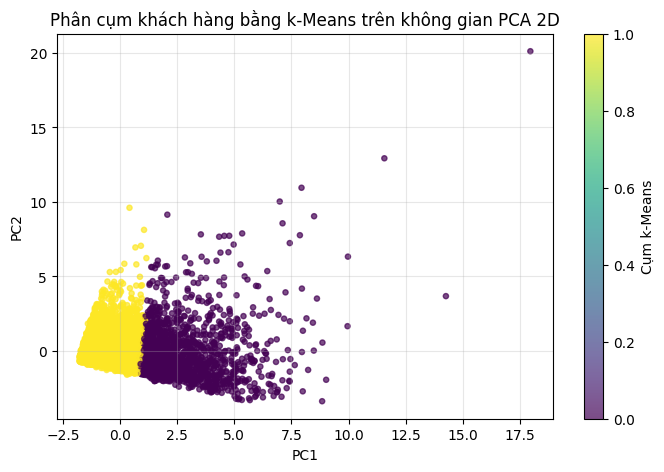

In [88]:
plt.scatter(
    X_pca_2d[:, 0],
    X_pca_2d[:, 1],
    c=model_df["kmeans_cluster"],
    s=14,
    alpha=0.7
)
plt.title("Phân cụm khách hàng bằng k-Means trên không gian PCA 2D")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True, alpha=0.3)
plt.colorbar(label="Cụm k-Means")
plt.show()

## 7. Phân tích đặc điểm từng cụm k-Means

Bảng dưới đây mô tả trung bình các biến số theo từng cụm. Cột `churned` được đưa vào phần phân tích sau khi phân cụm để xem tỷ lệ rời bỏ của từng nhóm, không dùng làm đầu vào khi huấn luyện k-Means.

In [89]:
profile_numeric_cols = [
    "age", "total_orders", "total_spend_usd", "avg_order_value_usd",
    "days_since_last_purchase", "reviews_given", "avg_review_score",
    "returns_made", "wishlist_items", "newsletter_subscribed",
    "customer_tenure_days", "churned"
]
profile_numeric_cols = [col for col in profile_numeric_cols if col in model_df.columns]

cluster_profile = model_df.groupby("kmeans_cluster")[profile_numeric_cols].mean().round(2)
cluster_size = model_df["kmeans_cluster"].value_counts().sort_index().rename("n_customers")
cluster_profile = pd.concat([cluster_size, cluster_profile], axis=1)
cluster_profile

,n_customers,age,total_orders,total_spend_usd,avg_order_value_usd,days_since_last_purchase,reviews_given,avg_review_score,returns_made,wishlist_items,newsletter_subscribed,customer_tenure_days,churned
kmeans_cluster,,,,,,,,,,,,,
0,1748,35.67,38.30,4027.02,114.28,57.80,8.58,4.13,2.67,4.49,0.62,613.24,0.06
1,6252,35.60,10.46,868.51,89.41,60.08,1.73,4.10,0.34,4.45,0.62,584.95,0.10


Kết quả phân cụm K-Means chia khách hàng thành hai nhóm có đặc điểm khác biệt rõ rệt về hành vi mua sắm. Cụm 0 gồm 1.748 khách hàng, tương đương 21,9% tổng số khách hàng. Nhóm này có số lượng đơn hàng trung bình 38,3 đơn và tổng chi tiêu trung bình 4.027,02 USD, cao hơn đáng kể so với cụm còn lại. Giá trị đơn hàng trung bình đạt 114,28 USD và số lượt đánh giá sản phẩm trung bình là 8,58 lượt. Tỷ lệ khách hàng rời bỏ trong nhóm chỉ khoảng 6%. Những đặc điểm này cho thấy đây là nhóm khách hàng có mức độ gắn bó cao, thường xuyên mua sắm và mang lại doanh thu lớn cho doanh nghiệp. Vì vậy, cụm 0 được đặt tên là "Khách hàng giá trị cao".

Cụm 1 gồm 6.252 khách hàng, chiếm 78,1% tổng số khách hàng. Nhóm này có số đơn hàng trung bình 10,46 đơn và tổng chi tiêu trung bình 868,51 USD. Mức độ tương tác với hệ thống cũng thấp hơn khi số lượt đánh giá trung bình chỉ đạt 1,73 lượt. Tỷ lệ khách hàng rời bỏ khoảng 10%, cao hơn cụm 0. Nhóm khách hàng này chủ yếu thực hiện các giao dịch với giá trị thấp và tần suất mua sắm không cao. Do đó, cụm 1 được đặt tên là "Khách hàng phổ thông".


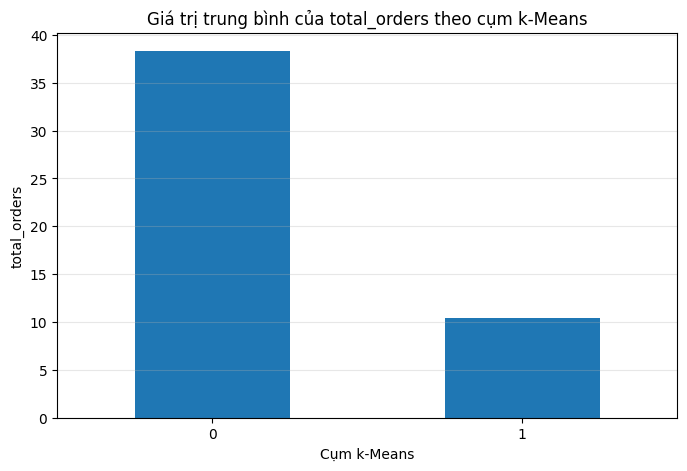

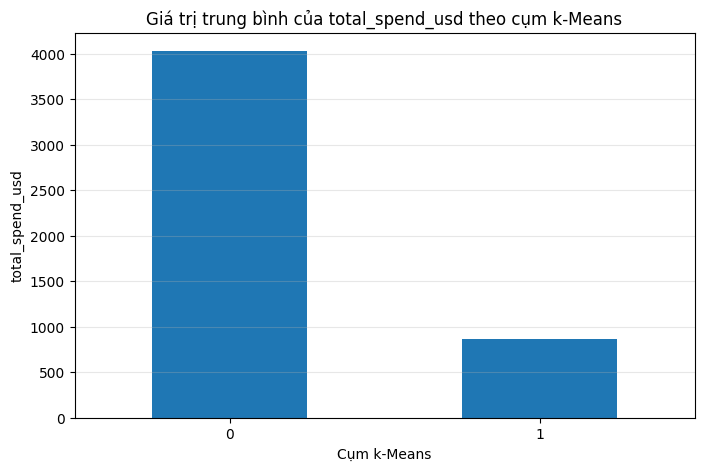

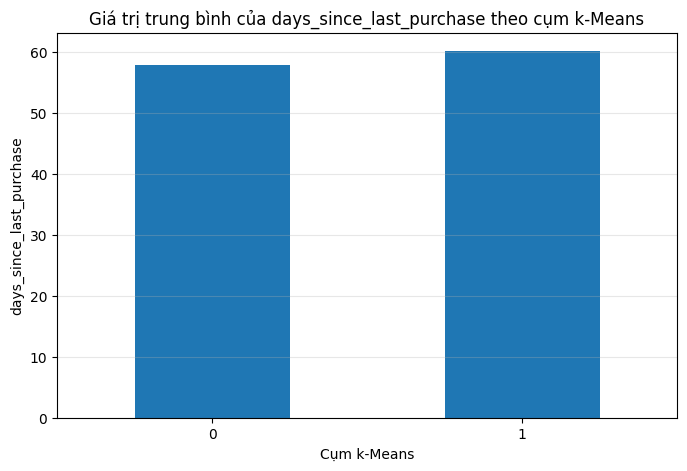

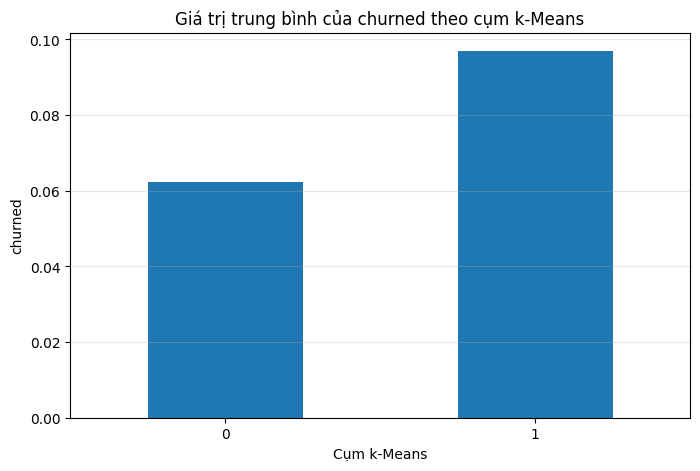

In [90]:
# Vẽ một số biến hành vi theo cụm
plot_cols = ["total_orders", "total_spend_usd", "days_since_last_purchase", "churned"]
plot_cols = [col for col in plot_cols if col in model_df.columns]

for col in plot_cols:
    values = model_df.groupby("kmeans_cluster")[col].mean().sort_index()
    values.plot(kind="bar")
    plt.title(f"Giá trị trung bình của {col} theo cụm k-Means")
    plt.xlabel("Cụm k-Means")
    plt.ylabel(col)
    plt.xticks(rotation=0)
    plt.grid(True, axis="y", alpha=0.3)
    plt.show()

In [91]:
# Phân tích nhanh biến phân loại nổi bật nhất trong từng cụm
categorical_summary = []
for cluster_id, group in model_df.groupby("kmeans_cluster"):
    row = {"kmeans_cluster": cluster_id, "n_customers": len(group)}
    for col in categorical_features:
        top_value = group[col].mode(dropna=True)
        row[f"top_{col}"] = top_value.iloc[0] if len(top_value) > 0 else np.nan
    categorical_summary.append(row)

pd.DataFrame(categorical_summary)

,kmeans_cluster,n_customers,top_country,top_gender,top_membership_tier,top_preferred_category,top_preferred_device,top_preferred_payment_method,top_acquisition_channel
0,0,1748,United States,Female,Free,Electronics,Mobile,Credit Card,Organic Search
1,1,6252,United States,Male,Free,Electronics,Mobile,Credit Card,Organic Search


## 8. DBSCAN: chọn eps và min_samples

DBSCAN cần hai tham số chính: `eps` và `min_samples`. Notebook dùng biểu đồ khoảng cách k-nearest neighbors để gợi ý vùng giá trị `eps`, sau đó thử nhiều tổ hợp tham số trên mẫu dữ liệu và chọn mô hình theo điểm Silhouette có xét thêm tỷ lệ nhiễu. Mô hình cuối được áp dụng cho toàn bộ khách hàng.

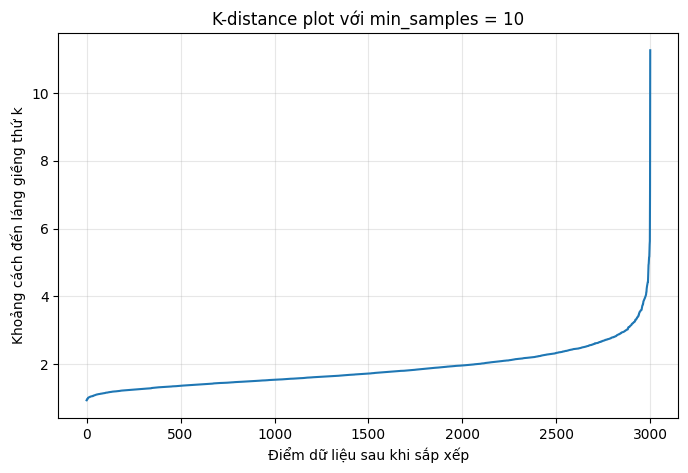

Các giá trị eps gợi ý từ phân vị của k-distance: [1.725 1.866 2.018 2.119 2.228 2.392 2.599 2.94 ]


In [92]:
min_samples_default = 10
neighbors = NearestNeighbors(n_neighbors=min_samples_default)
neighbors_fit = neighbors.fit(X_pca_sample)
distances, indices = neighbors_fit.kneighbors(X_pca_sample)
k_distances = np.sort(distances[:, -1])

plt.plot(k_distances)
plt.title(f"K-distance plot với min_samples = {min_samples_default}")
plt.xlabel("Điểm dữ liệu sau khi sắp xếp")
plt.ylabel("Khoảng cách đến láng giềng thứ k")
plt.grid(True, alpha=0.3)
plt.show()

candidate_eps = np.percentile(k_distances, [50, 60, 70, 75, 80, 85, 90, 95]).round(3)
print("Các giá trị eps gợi ý từ phân vị của k-distance:", candidate_eps)

thử nhiều tham số của DBSCAN và tìm ra cấu hình phân cụm tốt nhất.

In [93]:
def dbscan_metrics(X, labels):
    labels = np.asarray(labels)
    non_noise_mask = labels != -1
    n_noise = int((labels == -1).sum())
    noise_rate = n_noise / len(labels)
    unique_clusters = sorted(set(labels) - {-1})
    n_clusters = len(unique_clusters)

    result = {
        "n_clusters": n_clusters,
        "n_noise": n_noise,
        "noise_rate": noise_rate,
        "silhouette": np.nan,
        "davies_bouldin": np.nan,
        "calinski_harabasz": np.nan,
        "selection_score": -np.inf
    }

    if n_clusters >= 2 and non_noise_mask.sum() > n_clusters:
        X_valid = X[non_noise_mask]
        labels_valid = labels[non_noise_mask]
        sil = safe_silhouette(X_valid, labels_valid)
        result["silhouette"] = sil
        result["davies_bouldin"] = davies_bouldin_score(X_valid, labels_valid)
        result["calinski_harabasz"] = calinski_harabasz_score(X_valid, labels_valid)
        result["selection_score"] = sil * (1 - noise_rate)

    return result

min_samples_grid = [5, 10, 15, 20]
eps_grid = sorted(set(candidate_eps.tolist()))

dbscan_results = []
for min_samples in min_samples_grid:
    for eps in eps_grid:
        db = DBSCAN(eps=float(eps), min_samples=min_samples)
        labels = db.fit_predict(X_pca_sample)
        metrics = dbscan_metrics(X_pca_sample, labels)
        metrics.update({"eps": float(eps), "min_samples": min_samples})
        dbscan_results.append(metrics)

dbscan_eval = pd.DataFrame(dbscan_results)
dbscan_eval = dbscan_eval.sort_values("selection_score", ascending=False)
dbscan_eval

,n_clusters,n_noise,noise_rate,silhouette,davies_bouldin,calinski_harabasz,selection_score,eps,min_samples
2,2,308,0.102667,0.131456,2.605876,336.957445,0.117960,2.018,5
10,2,447,0.149000,0.132549,2.501864,345.741436,0.112800,2.018,10
18,2,549,0.183000,0.137420,2.428198,349.932294,0.112272,2.018,15
17,2,746,0.248667,0.146186,2.314861,350.065935,0.109834,1.866,15
25,2,839,0.279667,0.152235,2.274106,354.506679,0.109660,1.866,20
9,2,642,0.214000,0.139507,2.378961,347.795211,0.109652,1.866,10
8,2,887,0.295667,0.153464,2.259069,346.615281,0.108090,1.725,10
16,2,1022,0.340667,0.160523,2.196152,345.484654,0.105838,1.725,15
26,3,607,0.202333,0.131456,1.849848,205.936307,0.104858,2.018,20
24,2,1182,0.394000,0.167988,2.118060,337.626384,0.101801,1.725,20


In [94]:
best_dbscan_row = dbscan_eval.iloc[0]
best_eps = float(best_dbscan_row["eps"])
best_min_samples = int(best_dbscan_row["min_samples"])

print("eps được chọn:", best_eps)
print("min_samples được chọn:", best_min_samples)

best_dbscan = DBSCAN(eps=best_eps, min_samples=best_min_samples)
model_df["dbscan_cluster"] = best_dbscan.fit_predict(X_pca)

model_df["dbscan_cluster"].value_counts().sort_index()

eps được chọn: 2.018
min_samples được chọn: 5


,count
dbscan_cluster,
-1,458
0,2845
1,4688
2,4
3,5


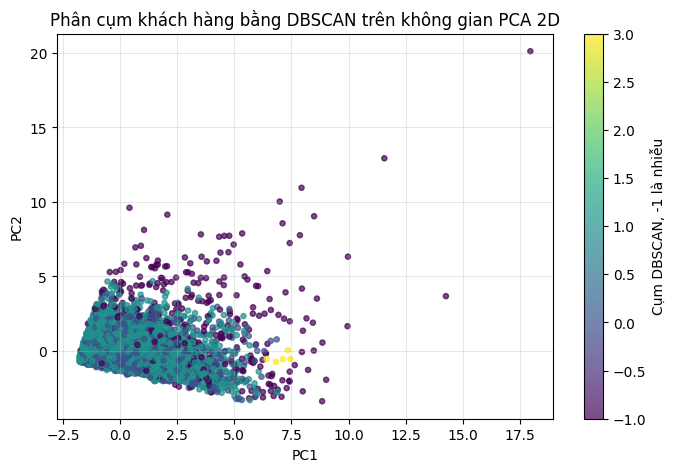

In [95]:
plt.scatter(
    X_pca_2d[:, 0],
    X_pca_2d[:, 1],
    c=model_df["dbscan_cluster"],
    s=14,
    alpha=0.7
)
plt.title("Phân cụm khách hàng bằng DBSCAN trên không gian PCA 2D")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True, alpha=0.3)
plt.colorbar(label="Cụm DBSCAN, -1 là nhiễu")
plt.show()

## 9. So sánh k-Means và DBSCAN

k-Means luôn gán mỗi khách hàng vào một cụm. DBSCAN có thể đánh dấu một số điểm là nhiễu với nhãn `-1`. Khi tính chỉ số cho DBSCAN, notebook loại các điểm nhiễu ra khỏi phần đánh giá nội bộ.

In [96]:
def clustering_summary(X, labels, model_name):
    labels = np.asarray(labels)
    non_noise_mask = labels != -1
    n_noise = int((labels == -1).sum())
    noise_rate = n_noise / len(labels)
    n_clusters = len(set(labels) - {-1})

    result = {
        "model": model_name,
        "n_clusters": n_clusters,
        "n_noise": n_noise,
        "noise_rate": noise_rate,
        "silhouette": np.nan,
        "davies_bouldin": np.nan,
        "calinski_harabasz": np.nan
    }

    if model_name == "k-Means":
        valid_X = X
        valid_labels = labels
    else:
        valid_X = X[non_noise_mask]
        valid_labels = labels[non_noise_mask]

    if len(set(valid_labels)) >= 2:
        result["silhouette"] = safe_silhouette(valid_X, valid_labels)
        result["davies_bouldin"] = davies_bouldin_score(valid_X, valid_labels)
        result["calinski_harabasz"] = calinski_harabasz_score(valid_X, valid_labels)

    return result

comparison = pd.DataFrame([
    clustering_summary(X_pca, model_df["kmeans_cluster"], "k-Means"),
    clustering_summary(X_pca, model_df["dbscan_cluster"], "DBSCAN")
])

comparison.round(4)

,model,n_clusters,n_noise,noise_rate,silhouette,davies_bouldin,calinski_harabasz
0,k-Means,2,0,0.0000,0.2512,1.8044,1679.9086
1,DBSCAN,4,458,0.0572,0.1270,1.6153,319.2035


Nhận xét khi đọc bảng so sánh:

- Silhouette Score cao hơn thường cho thấy cụm tách rõ hơn.
- Davies-Bouldin thấp hơn thường tốt hơn.
- Calinski-Harabasz cao hơn thường tốt hơn.
- Nếu DBSCAN có tỷ lệ nhiễu cao, kết quả khó dùng để phân nhóm khách hàng trong thực tế, dù Silhouette trên phần không nhiễu có thể cao.

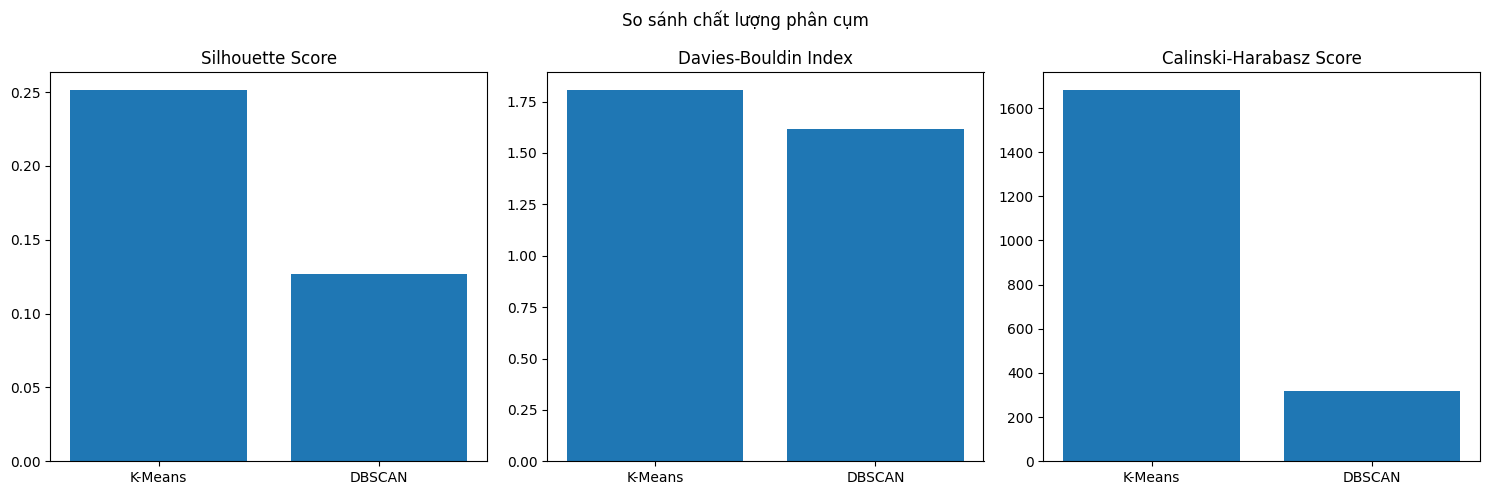

In [97]:

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15,5))

models = ['K-Means', 'DBSCAN']

axes[0].bar(models,[0.2512,0.1270])
axes[0].set_title('Silhouette Score')

axes[1].bar(models,[1.8044,1.6153])
axes[1].set_title('Davies-Bouldin Index')

axes[2].bar(models,[1679.9086,319.2035])
axes[2].set_title('Calinski-Harabasz Score')

plt.suptitle('So sánh chất lượng phân cụm')
plt.tight_layout()

plt.show()

## 10. Chuẩn bị dữ liệu cho k-NN và SVM

Bài toán phân lớp dùng biến mục tiêu `churned`. Đây là biến cho biết khách hàng có rời bỏ hay không. Dữ liệu được chia thành tập train và test theo tỷ lệ 80/20, có phân tầng theo `churned` để giữ cấu trúc lệch lớp.

In [98]:
import pandas as pd # Import pandas for DataFrame operations
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.compose import ColumnTransformer # Import ColumnTransformer
from sklearn.metrics import classification_report, confusion_matrix # Import for evaluation

# 1. Tách biến độc lập (X) và biến mục tiêu (y)
X = model_df[classification_features]
y = model_df['churned']

# 2. CHIA TẬP TRAIN/TEST TRƯỚC
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Định nghĩa preprocessor riêng cho phân lớp (moved from cell cef16585)
classification_numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
classification_categorical_features = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

# `numeric_transformer` và `categorical_transformer` đã được định nghĩa ở cell 3163d498
# và có sẵn trong môi trường kernel.
classification_preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, classification_numeric_features),
        ("cat", categorical_transformer, classification_categorical_features)
    ],
    remainder="drop"
)

# Pipeline
pipeline = Pipeline([
    ('preprocessor', classification_preprocessor), # Add the preprocessor to handle transformations
    ('smote', SMOTE(random_state=42)),
    ('svm', SVC(
        kernel='rbf',
        C=1.0,
        gamma='scale',
        probability=True,
        random_state=42
    ))
])

# Huấn luyện
pipeline.fit(X_train, y_train)

# Dự đoán
y_pred = pipeline.predict(X_test)

# Đánh giá hiệu năng mô hình (khôi phục từ các bản sửa đổi trước)
print("--- BÁO CÁO PHÂN LỚP (CLASSIFICATION REPORT) ---")
print(classification_report(y_test, y_pred))

print("--- MA TRẬN NHẦM LẪN (CONFUSION MATRIX) ---")
print(confusion_matrix(y_test, y_pred))

--- BÁO CÁO PHÂN LỚP (CLASSIFICATION REPORT) ---
              precision    recall  f1-score   support

           0       0.93      0.92      0.92      1457
           1       0.23      0.26      0.24       143

    accuracy                           0.86      1600
   macro avg       0.58      0.59      0.58      1600
weighted avg       0.86      0.86      0.86      1600

--- MA TRẬN NHẦM LẪN (CONFUSION MATRIX) ---
[[1334  123]
 [ 106   37]]


In [99]:
X = model_df[classification_features]
y = model_df[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)
print("Tỷ lệ churn trong train:")
print(y_train.value_counts(normalize=True).round(4))
print("Tỷ lệ churn trong test:")
print(y_test.value_counts(normalize=True).round(4))

Train: (6400, 18)
Test: (1600, 18)
Tỷ lệ churn trong train:
churned
0    0.9106
1    0.0894
Name: proportion, dtype: float64
Tỷ lệ churn trong test:
churned
0    0.9106
1    0.0894
Name: proportion, dtype: float64


In [100]:
# Preprocessor riêng cho phân lớp để tránh rò rỉ dữ liệu.
classification_numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
classification_categorical_features = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

classification_preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, classification_numeric_features),
        ("cat", categorical_transformer, classification_categorical_features)
    ],
    remainder="drop"
)

## 11. k-NN: chọn số K phù hợp

k-NN được đánh giá với nhiều giá trị K. Vì lớp `churned = 1` có tỷ lệ thấp hơn, notebook dùng F1-score của lớp dương để chọn K thay vì chỉ dùng Accuracy.

In [101]:
k_candidates = [3, 5, 7, 9, 11, 15, 21, 31]
knn_search_results = []

X_train_inner, X_val, y_train_inner, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y_train
)

for k in k_candidates:
    knn_pipeline = Pipeline(steps=[
        ("preprocess", classification_preprocessor),
        ("pca", PCA(n_components=N_PCA_COMPONENTS, random_state=RANDOM_STATE)),
        ("model", KNeighborsClassifier(n_neighbors=k))
    ])
    knn_pipeline.fit(X_train_inner, y_train_inner)
    val_pred = knn_pipeline.predict(X_val)
    val_f1 = f1_score(y_val, val_pred, zero_division=0)
    knn_search_results.append({
        "k": k,
        "validation_f1": val_f1
    })

knn_search_df = pd.DataFrame(knn_search_results).sort_values("validation_f1", ascending=False)
knn_search_df

,k,validation_f1
0,3,0.129730
1,5,0.127907
4,11,0.100629
3,9,0.100000
2,7,0.098160
5,15,0.066225
6,21,0.053691
7,31,0.041096


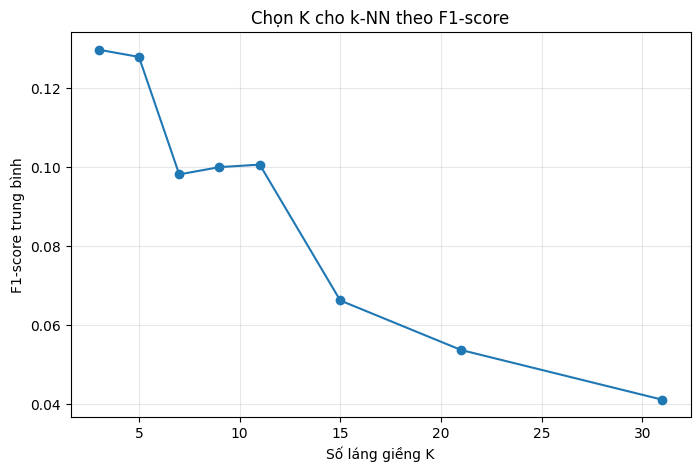

In [102]:
plt.plot(
    knn_search_df.sort_values("k")["k"],
    knn_search_df.sort_values("k")["validation_f1"],
    marker="o"
)
plt.title("Chọn K cho k-NN theo F1-score")
plt.xlabel("Số láng giềng K")
plt.ylabel("F1-score trung bình")
plt.grid(True, alpha=0.3)
plt.show()

In [103]:
best_knn_k = int(knn_search_df.iloc[0]["k"])
print("K được chọn cho k-NN:", best_knn_k)

knn_model = Pipeline(steps=[
    ("preprocess", classification_preprocessor),
    ("pca", PCA(n_components=N_PCA_COMPONENTS, random_state=RANDOM_STATE)),
    ("model", KNeighborsClassifier(n_neighbors=best_knn_k))
])

knn_model.fit(X_train, y_train)
y_pred_knn = knn_model.predict(X_test)
y_proba_knn = knn_model.predict_proba(X_test)[:, 1]

K được chọn cho k-NN: 3


## 12. SVM: huấn luyện mô hình phân lớp

SVM được triển khai bằng LinearSVC. Đây là mô hình SVM tuyến tính, chạy nhanh và phù hợp với dữ liệu đã chuẩn hóa, mã hóa và giảm chiều bằng PCA. Tham số `class_weight="balanced"` được dùng vì dữ liệu có lệch lớp giữa nhóm chưa rời bỏ và nhóm đã rời bỏ.

In [104]:
svm_model = Pipeline(steps=[
    ("preprocess", classification_preprocessor),
    ("pca", PCA(n_components=N_PCA_COMPONENTS, random_state=RANDOM_STATE)),
    ("model", LinearSVC(class_weight="balanced", random_state=RANDOM_STATE, max_iter=5000))
])

svm_model.fit(X_train, y_train)
y_pred_svm = svm_model.predict(X_test)
y_score_svm = svm_model.decision_function(X_test)

## 13. Đánh giá mô hình k-NN và SVM

Các chỉ số dùng để đánh giá gồm Accuracy, Precision, Recall, F1-score và ROC-AUC. Với dữ liệu lệch lớp, F1-score và Recall của lớp `churned = 1` thường có ý nghĩa hơn Accuracy.

In [105]:
def evaluate_classifier(name, y_true, y_pred, y_proba):
    return {
        "model": name,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1_score": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_proba)
    }

classification_results = pd.DataFrame([
    evaluate_classifier("k-NN", y_test, y_pred_knn, y_proba_knn),
    evaluate_classifier("SVM", y_test, y_pred_svm, y_score_svm)
])

classification_results.round(4)

,model,accuracy,precision,recall,f1_score,roc_auc
0,k-NN,0.8981,0.2619,0.0769,0.1189,0.5697
1,SVM,0.6575,0.1466,0.5874,0.2346,0.6867


In [106]:
print("Classification report cho k-NN")
print(classification_report(y_test, y_pred_knn, zero_division=0))

print("Classification report cho SVM")
print(classification_report(y_test, y_pred_svm, zero_division=0))

Classification report cho k-NN
              precision    recall  f1-score   support

           0       0.92      0.98      0.95      1457
           1       0.26      0.08      0.12       143

    accuracy                           0.90      1600
   macro avg       0.59      0.53      0.53      1600
weighted avg       0.86      0.90      0.87      1600

Classification report cho SVM
              precision    recall  f1-score   support

           0       0.94      0.66      0.78      1457
           1       0.15      0.59      0.23       143

    accuracy                           0.66      1600
   macro avg       0.54      0.63      0.51      1600
weighted avg       0.87      0.66      0.73      1600



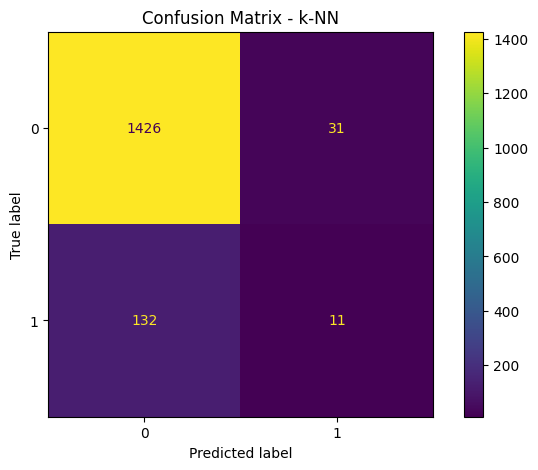

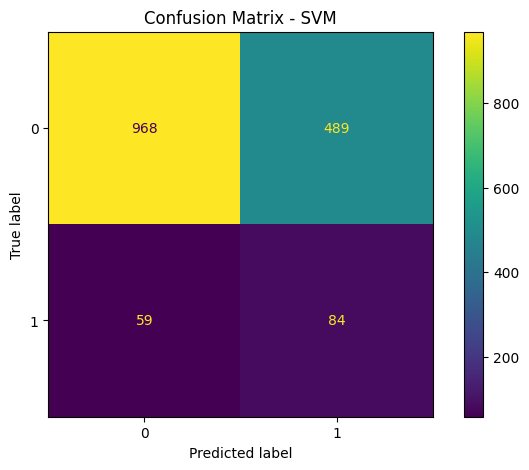

In [107]:
fig, ax = plt.subplots()
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_knn, ax=ax)
plt.title("Confusion Matrix - k-NN")
plt.show()

fig, ax = plt.subplots()
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_svm, ax=ax)
plt.title("Confusion Matrix - SVM")
plt.show()

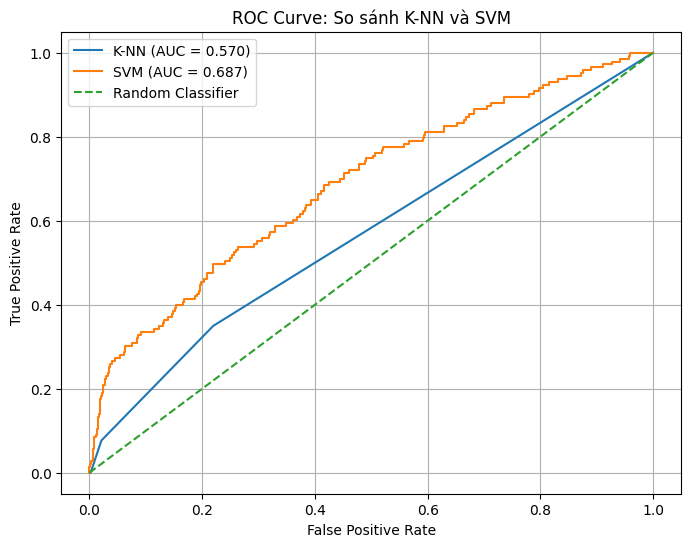

K-NN ROC-AUC: 0.5697
SVM ROC-AUC: 0.6867


In [108]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Xác suất dự đoán lớp churn (class=1) cho k-NN
knn_probs = knn_model.predict_proba(X_test)[:, 1]
# Điểm quyết định cho lớp churn (class=1) của SVM
svm_scores = svm_model.decision_function(X_test)

# Tính ROC
fpr_knn, tpr_knn, _ = roc_curve(y_test, knn_probs)
fpr_svm, tpr_svm, _ = roc_curve(y_test, svm_scores)

# Tính AUC
auc_knn = roc_auc_score(y_test, knn_probs)
auc_svm = roc_auc_score(y_test, svm_scores)

# Vẽ ROC Curve
plt.figure(figsize=(8,6))

plt.plot(
    fpr_knn,
    tpr_knn,
    label=f'K-NN (AUC = {auc_knn:.3f})'
)

plt.plot(
    fpr_svm,
    tpr_svm,
    label=f'SVM (AUC = {auc_svm:.3f})'
)

plt.plot(
    [0,1],
    [0,1],
    linestyle='--',
    label='Random Classifier'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve: So sánh K-NN và SVM')
plt.legend()
plt.grid(True)

plt.show()

print(f"K-NN ROC-AUC: {auc_knn:.4f}")
print(f"SVM ROC-AUC: {auc_svm:.4f}")

## 14. Nhận xét kết quả

Có thể viết nhận xét dựa trên kết quả chạy thực tế của notebook như sau:

1. Với k-Means, số cụm được chọn dựa trên Silhouette Score. Nếu đồ thị Elbow có điểm gãy gần với giá trị này, lựa chọn số cụm có cơ sở hơn. Sau khi phân cụm, bảng đặc điểm cụm cho biết nhóm nào có tổng chi tiêu cao, nhóm nào ít mua hàng, nhóm nào có khoảng cách mua gần nhất lớn và nhóm nào có tỷ lệ rời bỏ cao hơn.

2. Với DBSCAN, kết quả phụ thuộc nhiều vào `eps` và `min_samples`. Nếu DBSCAN tạo nhiều điểm nhiễu, mô hình này chưa phù hợp để chia nhóm khách hàng trong bộ dữ liệu này. Nếu DBSCAN tạo được từ hai cụm trở lên với tỷ lệ nhiễu thấp, có thể dùng để phát hiện các nhóm khách hàng có mật độ hành vi tương đồng.

3. Khi so sánh k-Means và DBSCAN, không nên nhìn một chỉ số đơn lẻ. k-Means dễ diễn giải vì mọi khách hàng đều có nhãn cụm. DBSCAN hữu ích khi dữ liệu có cấu trúc mật độ rõ và có nhiều điểm ngoại lai.

4. Với k-NN và SVM, dữ liệu có lệch lớp vì nhóm `churned = 1` thấp hơn nhóm `churned = 0`. Vì vậy Accuracy có thể cao dù mô hình dự đoán kém nhóm khách hàng rời bỏ. Cần ưu tiên F1-score, Recall và ROC-AUC khi đánh giá mô hình phân lớp.

5. Nếu SVM có Recall hoặc F1-score cao hơn k-NN, SVM phù hợp hơn cho mục tiêu phát hiện khách hàng có khả năng rời bỏ. Nếu k-NN có kết quả tương đương nhưng dễ giải thích hơn, có thể chọn k-NN cho bài toán minh họa.

## 15. Xuất dữ liệu kết quả nếu cần

Cell dưới đây lưu bảng khách hàng kèm nhãn cụm k-Means và DBSCAN. File này giúp kiểm tra từng khách hàng thuộc cụm nào.

In [110]:
output_cols = ["customer_id", "kmeans_cluster", "dbscan_cluster", "churned"]
output_cols = [col for col in output_cols if col in model_df.columns]

model_df[output_cols].to_csv("customer_cluster_results.csv", index=False)
classification_results.to_csv("classification_model_results.csv", index=False)
comparison.to_csv("clustering_model_comparison.csv", index=False)

print("Đã lưu:")
print("- customer_cluster_results.csv")
print("- classification_model_results.csv")
print("- clustering_model_comparison.csv")

Đã lưu:
- customer_cluster_results.csv
- classification_model_results.csv
- clustering_model_comparison.csv
